In [1]:
import numpy as np
from mpi4py import MPI

from dolfinx import mesh, fem
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem,
    create_matrix, 
    create_vector, 
)
from petsc4py import PETSc

import ufl

from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
    extract_function_spaces,
)

from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square, locate_entities, meshtags, CellType
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    sqrt,
    ln,
    lhs,
    rhs,
    conditional,
    derivative,
)

from petsc4py import PETSc
import numpy as np
import pyvista

from visualization_fct import *



In [12]:
def create_quad_domain(comm, nx, ny, p0, p1, p2, p3):
    """
    Create a domain defined by four corner points.

    Args:
        comm (mpi4py.MPI.Intracomm): MPI communicator
        nx (int): number of cells in x-direction
        ny (int): number of cells in y-direction
        p0 (np.array): x and y coordinates of the bottom-left corner point
        p1 (np.array): x and y coordinates of the bottom-right corner point
        p2 (np.array): x and y coordinates of the top-right corner point
        p3 (np.array): x and y coordinates of the top-left corner point

    Returns:
        dolfinx.mesh: Domain defined by the corner points.
    """

    mesh = create_unit_square(comm, nx, ny, cell_type=CellType.triangle)

    x = mesh.geometry.x
    xi = x[:, 0]
    eta = x[:, 1]

    x[:, :2] = (
        np.outer((1-xi)*(1-eta), p0) +
        np.outer(xi*(1-eta), p1) +
        np.outer(xi*eta, p2) +
        np.outer((1-xi)*eta, p3)
    )
    return mesh

In [13]:
# -------------------------------------------------
# Mesh
# -------------------------------------------------
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 15, 15, P0, P1, P2, P3)

tdim = domain.topology.dim

# -------------------------------------------------
# FE spaces
# -------------------------------------------------

V = fem.functionspace(domain, ("CG", 1))   # pressure head
Q = fem.functionspace(domain, ("DG", 0))   # material parameters


In [14]:

# -------------------------------------------------
# DG0 parameter fields
# -------------------------------------------------

Ks      = fem.Function(Q)
alpha   = fem.Function(Q)
n_vg    = fem.Function(Q)
theta_r = fem.Function(Q)
theta_s = fem.Function(Q)

# -------------------------------------------------
# Material assignment
# -------------------------------------------------

# Interface
slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

num_cells = domain.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)

midpoints = mesh.compute_midpoints(domain, tdim, cells)

Ks_vals      = np.zeros(num_cells)
alpha_vals   = np.zeros(num_cells)
n_vals       = np.zeros(num_cells)
theta_r_vals = np.zeros(num_cells)
theta_s_vals = np.zeros(num_cells)

for c, x in enumerate(midpoints):

    y = x[1]

    # ---------------------------------------------
    # Material 1 (lower half)
    # ---------------------------------------------
    if y <= slope*x[0] + P3[1]/2:
        # loam
        Ks_vals[c]      = 2.89e-6
        alpha_vals[c]   = 3.6
        n_vals[c]       = 1.56
        theta_r_vals[c] = 0.078
        theta_s_vals[c] = 0.43

    # ---------------------------------------------
    # Material 2 (upper half)
    # ---------------------------------------------
    elif y >= slope*x[0] + P3[1]/2:
        # sand
        Ks_vals[c]      = 8.25e-5
        alpha_vals[c]   = 14.5
        n_vals[c]       = 2.68
        theta_r_vals[c] = 0.045
        theta_s_vals[c] = 0.43

# -------------------------------------------------
# Store into DG0 functions
# -------------------------------------------------

Ks.x.array[:]      = Ks_vals
alpha.x.array[:]   = alpha_vals
n_vg.x.array[:]    = n_vals
theta_r.x.array[:] = theta_r_vals
theta_s.x.array[:] = theta_s_vals

Ks.x.scatter_forward()
alpha.x.scatter_forward()
n_vg.x.scatter_forward()
theta_r.x.scatter_forward()
theta_s.x.scatter_forward()


In [ ]:

# -------------------------------------------------
# Unknowns
# -------------------------------------------------

h  = fem.Function(V)
x = SpatialCoordinate(domain)
v = ufl.TestFunction(V)

# Initial condition
h.interpolate(lambda x: np.maximum(x[1], 0))

# -------------------------------------------------
# Van Genuchten constitutive relations
# -------------------------------------------------

def Saturation(u, alpha, N):
    eps = 1e-8
    u = conditional(u > eps, u, eps) # only use 'safe' values > 0
    a1 = 1 + exp(ln(alpha * u)*N)
    exp1 = (1 - N) / N
    S = exp(ln(a1)*exp1)
    return S

def k(u, alpha, N, Ks):
    S = Saturation(u, alpha, N)
    m = N / (N-1)
    a1 = 1 - exp(ln(S)*m)
    a2 = 1 - exp(ln(a1) / m)
    kr = sqrt(S) * a2 ** 2
    return kr*Ks




In [16]:
# Boundary conditions

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [17]:
# Define boundary conditions
c_in = 2e-9 # recharge
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

bcs = []
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)

In [18]:
# -------------------------------------------------
# Richards equation
# -------------------------------------------------

x = ufl.SpatialCoordinate(domain)

F = (inner(k(h, alpha, n_vg, Ks) * grad(x[1] - h), grad(v)) * dx) - v*c_in*ds(4)

residual = fem.form(F)
J = ufl.derivative(F, h)
jacobian = fem.form(J)




In [19]:
petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

problem = NonlinearProblem(
    F,
    h,
    bcs=bcs,
    J=J,
    petsc_options=petsc_options,
    petsc_options_prefix="RichardsSNES_",
)



h = problem.solve()
converged = problem.solver.getConvergedReason()
num_iter = problem.solver.getIterationNumber()
assert converged > 0, f"Solver did not converge, got {converged}."
print(
    f"Solver converged after {num_iter} iterations with converged reason {converged}."
)

  0 SNES Function norm 5.376620993686e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.376620993686e-06
    1 KSP Residual norm 2.566855373395e-21
  1 SNES Function norm 5.372519119629e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.372519119629e-06
    1 KSP Residual norm 1.758987879884e-19
  2 SNES Function norm 5.371377656077e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.371377656077e-06
    1 KSP Residual norm 6.916517850794e-19
  3 SNES Function norm 5.360399940853e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.360399940853e-06
    1 KSP Residual norm 7.865265480487e-20
  4 SNES Function norm 5.341984378757e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.341984378757e-06
    1 KSP Residual norm 4.689832252770e-20
  5 SNES Function norm 5.221581670160e-06
    Residual norms for RichardsSNES_ solve.
    0 KSP Residual norm 5.221581670160e-06
    1 KSP R

In [20]:
# Number of points along each edge
n = 15

# Create parameter space
x_int = np.linspace(0, 1, n)
y_int = np.linspace(0, 1, n)
x_int, y_int = np.meshgrid(x_int, y_int)

# Bilinear interpolation
x = (1 - x_int) * (1 - y_int) * P0[0] + x_int * (1 - y_int) * P1[0] + x_int * y_int * P2[0] + (1 - x_int) * y_int * P3[0]
y = (1 - x_int) * (1 - y_int) * P0[1] + x_int * (1 - y_int) * P1[1] + x_int * y_int * P2[1] + (1 - x_int) * y_int * P3[1]

# Combine into a grid of points
grid = np.column_stack((x.ravel(), y.ravel()))

# Evaluate u on grid
h = eval_fct_on_grid(grid, [h], domain).reshape((n,n))
x = x.reshape((n,n))
z = y.reshape((n,n))


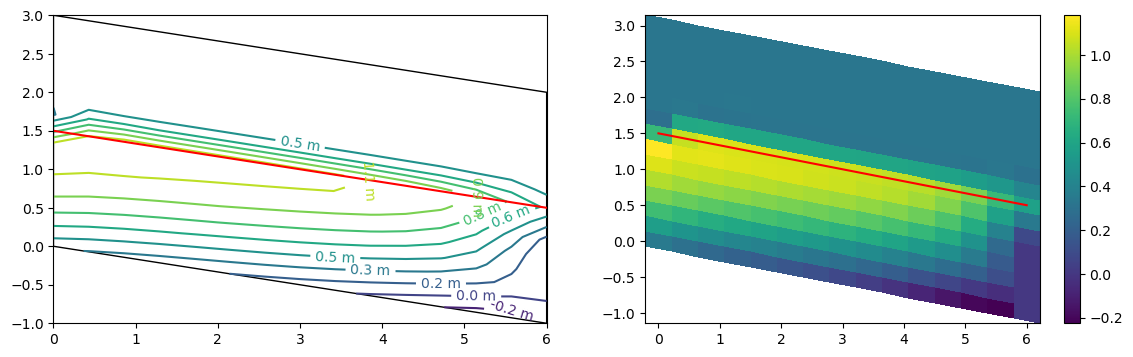

In [21]:
from matplotlib.patches import Polygon

fig, ax = plt.subplots(1,2, figsize=(14,4))
con = ax[0].contour(x, z, h, levels=10)
ax[0].clabel(con, fmt="%1.1f m")
# add black box around domain
polygon = Polygon([P1, P2, P3, P0], fill=False, edgecolor='black')
ax[0].add_patch(polygon)
# add line at layer interface
x_l = np.linspace(P0[0], P1[0], 100)
interface = slope*x_l+P3[1]/2
ax[0].plot(x_l, interface, color="red")

pmesh = ax[1].pcolormesh(x, z, h)
ax[1].plot(x_l, interface, color="red")
fig.colorbar(pmesh, ax = ax[1])



gleiches Ergebnis wie in heterogen_flexibler... (aber auch gleicher Ansatz)